# <center> Redes neuronales para el Procesamiento del Lenguaje Natural </center>  


# Práctica 5: Grandes Modelos de Lenguaje (Large Language Models - LLMs)
## Jesús Ferrándiz Alarcón

En esta práctica vamos a abordar un problema de Análisis de Sentimientos mediante el uso LLMs.

En esta práctica he decidido utilizar el siguiente modelo:
[mistralai/Mistral-7B-Instruct-v0.3](https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.3)

Como menciona la documentación, se trata de un LLM del tipo **instruct**, es decir, ha sido ajustado para seguir prompts de usuarios, realizar tareas y seguir instrucciones.

He decidido ejecutar este modelo en local para no tener problemas de límites con APIs. De esta manera, he podido realizar las evaluaciones en todas las muestras de test.

Este modelo tiene **7B** de parámetros. Si se utiliza el modelo tal cual, ocupa 28GB de VRAM. Tengo una GPU RTX 3090 que tiene 24GB de VRAM.
He optado por la solución de utilizar una versión **cuantizada** del modelo. Es decir, convertir los pesos de una resolución float32 a int8.
De esta manera, el modelo ocupa **7GB** en VRAM.

Con esto hay un riesgo de que la accuracy/precisión del modelo varie al cambiar la resolución de los pesos. Pero es una técnica ampliamente utilizada y quería también familiarizarme con ella.
https://huggingface.co/docs/optimum/concept_guides/quantization

# Imports

Similar a prácticas anteriores comenzamos con una serie de imports que usaremos para cargar el dataset y hacer instrospección de este.

In [2]:
# Librerias necesarias
# Matplotlib conf
import matplotlib.pyplot as plt
%matplotlib inline
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':40,
         'ytick.labelsize': 40
}
plt.rcParams.update(params)
# Seaborn conf
import seaborn as sns
sns.set(style='darkgrid')
sns.set_palette(sns.color_palette("Blues"))

import sys

#Procesado de datos
import pandas as pd
import numpy as np
import operator

#Modelos
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Carga del Dataset, introspección y procesado
Cargamos el dataset como en las prácticas anteriores. Los datos tabulares en .csv se
leen y cargan en una estructura de pandas.

## Carga del dataset

In [3]:
training_set = pd.read_csv('./Dataset_reviews/train_reviews.csv')
print(f"Training set shape: {training_set.shape},* columns: {training_set.columns.tolist()}")
test_set = pd.read_csv('./Dataset_reviews/test_reviews.csv')
print(f"Test set shape: {test_set.shape}, columns: {test_set.columns.tolist()}")

Training set shape: (8000, 3),* columns: ['id', 'review', 'sentiment']
Test set shape: (2000, 3), columns: ['id', 'review', 'sentiment']


In [4]:
# Inspeccionamos el aspecto del conjunto de entrenamiento
training_set.head(20)

,id,review,sentiment
0,17527,People tried to make me believe that the premi...,negative
1,24155,I have been wanting to see cut since the day i...,positive
2,21972,This movie is terrible. The suspense is spent ...,negative
3,4565,I hope she can keep acting and directing. She'...,positive
4,22098,I fell in love with this silent action drama. ...,positive
5,5138,Shame Shame Shame on UA/DW for what you do! <b...,negative
6,16932,It's not very often a movie can literally make...,positive
7,13181,I was very interested to see this movie when i...,positive
8,3299,It might not be the best movie of 2006 but it ...,positive
9,18982,I went to see the Omega Code with a group of o...,negative


Revisamos el balance de clases.

([0, 1], [Text(0, 0, 'positive'), Text(1, 0, 'negative')])

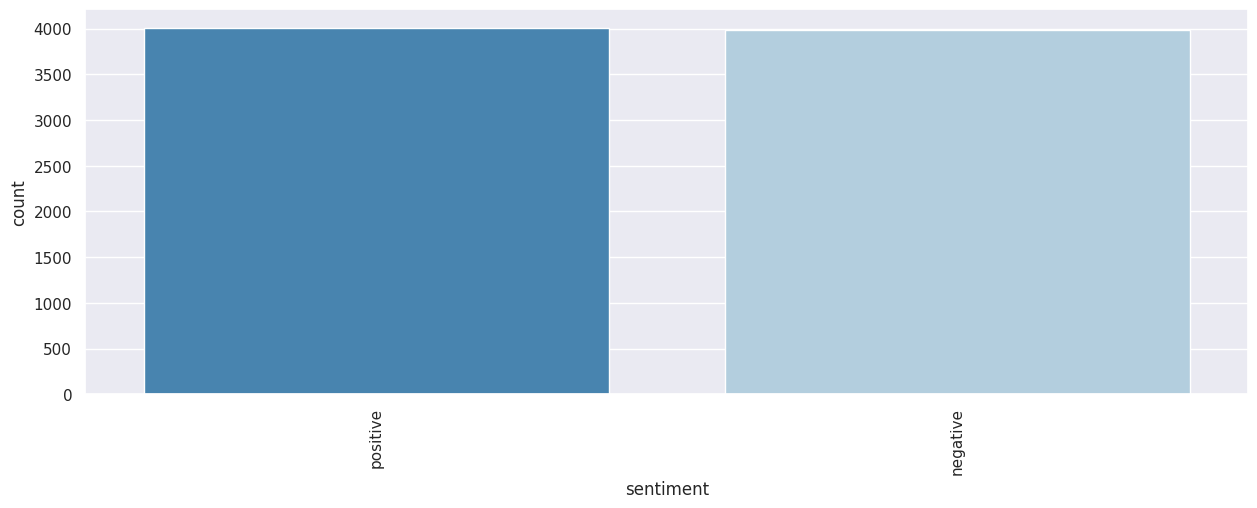

In [5]:
from collections import Counter
sns.countplot(data=training_set, x=training_set.sentiment, order=[x for x, count in sorted(Counter(training_set.sentiment).items(), key=lambda x: -x[1])], palette="Blues_r")
plt.xticks(rotation=90)

Hay un equilibrio entre el número de muestras de reseñas positivas y negativas.

A continuación vamos a procesar las reseñas. A diferencia con las prácticas anteriores, en este procesado, solo vamos a aplicar la eliminación de artefactos HTML. Esto se debe a que los modelos basados en LLMs implementarán sus propias técnicas de pre procesado, aquellas con la que el modelo ha sido entrenado.

Procesamos las reseñas solamente con:
- Eliminación de artefactos HTML


In [6]:
from bs4 import BeautifulSoup
import re

def strip_html_remove_links(text):
    soup = BeautifulSoup(text, "html.parser")
    for a in soup.find_all("a"):
        a.decompose()

    text = soup.get_text(separator=" ")

    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [7]:
def process_text(raw_text):
    text = strip_html_remove_links(raw_text)
    return text

In [8]:
dataset = pd.concat([training_set, test_set])
dataset.shape
dataset.columns

Index(['id', 'review', 'sentiment'], dtype='str')

In [9]:
dataset['id']

0       17527
1       24155
2       21972
3        4565
4       22098
        ...  
1995    11413
1996    10404
1997    22277
1998    18576
1999    21388
Name: id, Length: 10000, dtype: int64

Quiero utilizar el id para identificar muestras en las que se ha hecho inferencia, en el caso de no hacer inferencia de todas las muestras de test. Quiero asegurar que todas las muestras tienen un id distinto.

In [10]:
assert dataset['id'].is_unique, "Hay IDs duplicados!"

In [11]:
from tqdm import tqdm
tqdm.pandas()

dataset['processed_review'] = dataset['review'].progress_apply(lambda x: process_text(x))

100%|██████████| 10000/10000 [00:01<00:00, 7199.83it/s]


In [12]:
X_train = dataset[0:len(training_set)][["id", "processed_review"]]
y_train = dataset[0:len(training_set)][["sentiment"]]

X_test = dataset[len(training_set):len(dataset)][["id", "processed_review"]]
y_test = dataset[len(training_set):len(dataset)][["sentiment"]]

Codificamos las etiquetas del string 'positive', 'negative' a un
vector plano de 0's y 1's.
Donde 0 -> negative, 1 -> positive

In [13]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
print(f"Values before encoding: {y_train.sentiment.values}")
le.fit(y_train.sentiment.values)
target_labels = le.classes_
encoded_y_train = le.transform(y_train.sentiment.values)
print(f"Labels after encoding: {encoded_y_train}")

print(f"Target labels: {target_labels}")

encoded_y_test = le.transform(y_test.sentiment.values)


Values before encoding: <ArrowStringArray>
['negative', 'positive', 'negative', 'positive', 'positive', 'negative',
 'positive', 'positive', 'positive', 'negative',
 ...
 'negative', 'positive', 'positive', 'negative', 'positive', 'negative',
 'positive', 'negative', 'negative', 'negative']
Length: 8000, dtype: str
Labels after encoding: [0 1 0 ... 0 0 0]
Target labels: ['negative' 'positive']


In [14]:
Y_train = encoded_y_train  # Shape: (n_samples,)
Y_test = le.transform(y_test.values)

print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

print(Y_train[0:10])

Y_train shape: (8000,)
Y_test shape: (2000,)
[0 1 0 1 1 0 1 1 1 0]


## Conversión del dataset al formato de Hugging Face

Para evaluar modelos de la librería **transformers** de Hugging Face necesitamos convertir nuestro dataset actualmente cargado en estrucuras de pandas a un dataset de la librería **dataset** de Hugging Face. De esta manera podemos evaluar estos modelos en batches por ejemplo y entrenarlos (aunque en esta práctica no vamos a entrenar).

En este paso también hacemos el split del dataset de train (8000 muestras) en **train** (80% - 6400 muestras) y **validación** (20% 1600 muestras).

In [15]:
from datasets import Dataset, DatasetDict, ClassLabel

# Usamos la columna processed_review
train_df = pd.DataFrame({
    "text": X_train["processed_review"].values,
    "id": X_train["id"].values,
    "label": encoded_y_train,
})

# Cogemos también las etiquetas
test_df = pd.DataFrame({
    "text": X_test["processed_review"].values,
    "id": X_test["id"].values,
    "label": encoded_y_test
})

# La conversión desde pandas dataframes es directa
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Hacemos este casting para entender mejor las etiquetas
class_label = ClassLabel(names=list(target_labels))
train_dataset = train_dataset.cast_column("label", class_label)
test_dataset = test_dataset.cast_column("label", class_label)

# Aquí se hace el split en train y validation
train_val_split = train_dataset.train_test_split(test_size=0.2, seed=42)

dataset_dict = DatasetDict({
    "train": train_val_split["train"],
    "validation": train_val_split["test"],
    "test": test_dataset
})

print(dataset_dict)
print(f"Train example: {dataset_dict['train'][0]}")
print(f"Label mapping: {dict(enumerate(target_labels))}")

# Revisamos los mapping de label ids (0, 1) y label (negative, positive)
id2label = {i: label for i, label in enumerate(target_labels)}
label2id = {label: i for i, label in enumerate(target_labels)}
print(f"id 2 label: {id2label}")
print(f"label 2 id: {label2id}")

Casting the dataset: 100%|██████████| 2000/2000 [00:00<00:00, 1198543.79 examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'id', 'label'],
        num_rows: 6400
    })
    validation: Dataset({
        features: ['text', 'id', 'label'],
        num_rows: 1600
    })
    test: Dataset({
        features: ['text', 'id', 'label'],
        num_rows: 2000
    })
})
Train example: {'text': "My husband and I went to see this movie, being the horror movie buffs that we are. Two hours later I found myself wanting both my money and time back. I was so disappointed. The teasers for this film basically contained the best points of the film. There was nothing very scary about the film other than good timing on surprise entrances, etc. I found most of the 'scary' parts to be more comical than anything. After viewing other movies based on the works of Japanese writers, I have to conclude that what is deemed frightening in Japan is not what is frightening here in the US. My advice: If you are a fan of true horror movies, save yourself the pain of sitting throu

## Introspección

Posteriormente, tomaremos ciertas decisiones sobre el tamaño máximo de las secuencias de entrada a la hora de hacer el fine tuning de un modelo. Por este motivo, quiero revisar la distribución de las longitudes de las reviews procesadas en términos de conteo de palabras y conteo de carácteres.

Train: Mean=1307.36828125, Median=961.0, Min=64, Max=13593, Std=989.3630916024566
Validation: Mean=1322.28125, Median=989.0, Min=132, Max=6395, Std=977.6067606141221
Test: Mean=1305.2035, Median=966.0, Min=52, Max=10254, Std=975.5056653283722


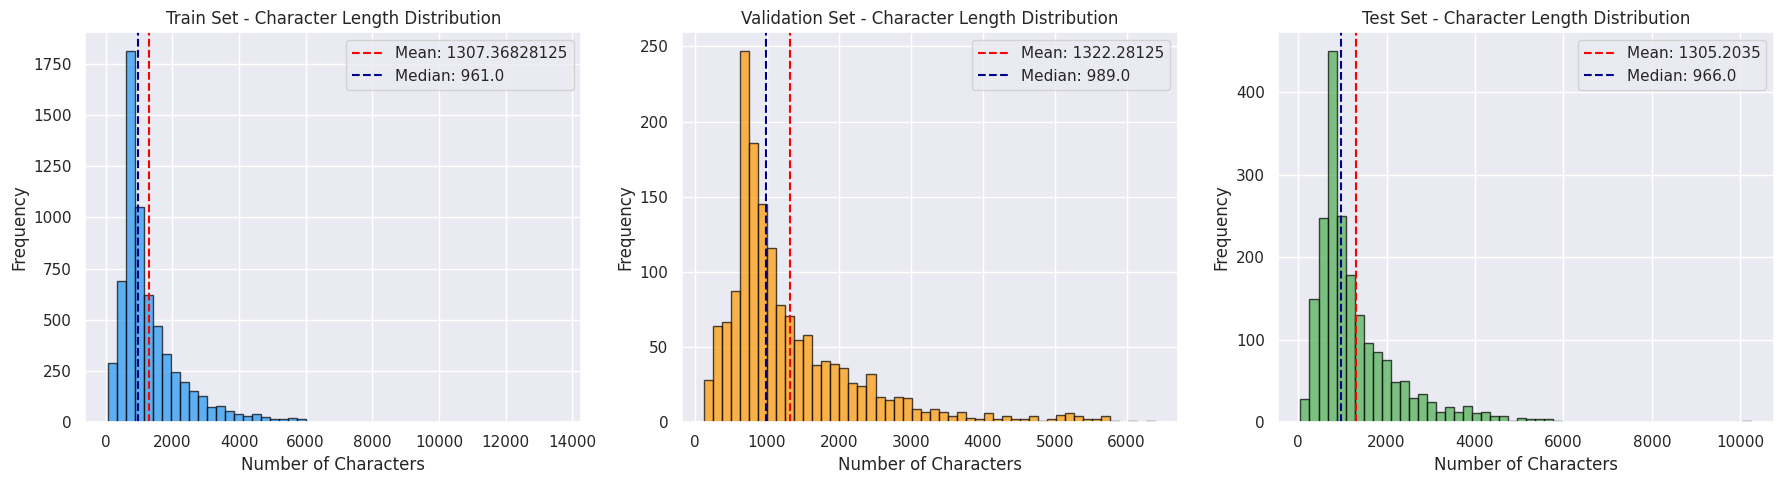

In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

splits = {
    "Train": dataset_dict["train"]["text"],
    "Validation": dataset_dict["validation"]["text"],
    "Test": dataset_dict["test"]["text"]
}

colors = ["#2196F3", "#FF9800", "#4CAF50"]

for ax, (split_name, texts), color in zip(axes, splits.items(), colors):
    char_lengths = [len(t) for t in texts]

    ax.hist(char_lengths, bins=50, color=color, edgecolor="black", alpha=0.7)
    ax.axvline(np.mean(char_lengths), color="red", linestyle="--",
               label=f"Mean: {np.mean(char_lengths)}")
    ax.axvline(np.median(char_lengths), color="darkblue", linestyle="--",
               label=f"Median: {np.median(char_lengths)}")
    ax.set_title(f"{split_name} Set - Character Length Distribution")
    ax.set_xlabel("Number of Characters")
    ax.set_ylabel("Frequency")
    ax.legend()

    print(f"{split_name}: Mean={np.mean(char_lengths)}, "
          f"Median={np.median(char_lengths)}, "
          f"Min={np.min(char_lengths)}, Max={np.max(char_lengths)}, "
          f"Std={np.std(char_lengths)}")

plt.tight_layout()
plt.show()

Tenemos en todos los sets una mediana generalmente de casi 1000 carácteres. Se ve algún outlier de tamaño 10254.
Es cierto que en este punto deberíamos fijarnos solamente en los sets de entrenamiento y validación. Consideraría un tamaño máximo de 6000 carácteres.

A continuación haremos lo mismo contando palabras, separando por espacios en blanco.

Train: Mean=232.32203125, Median=173.0, Min=12, Max=2459, Std=172.68336779963502
Validation: Mean=234.566875, Median=176.0, Min=27, Max=1070, Std=170.30122365307412
Test: Mean=232.378, Median=172.0, Min=10, Max=1832, Std=170.91052956444784


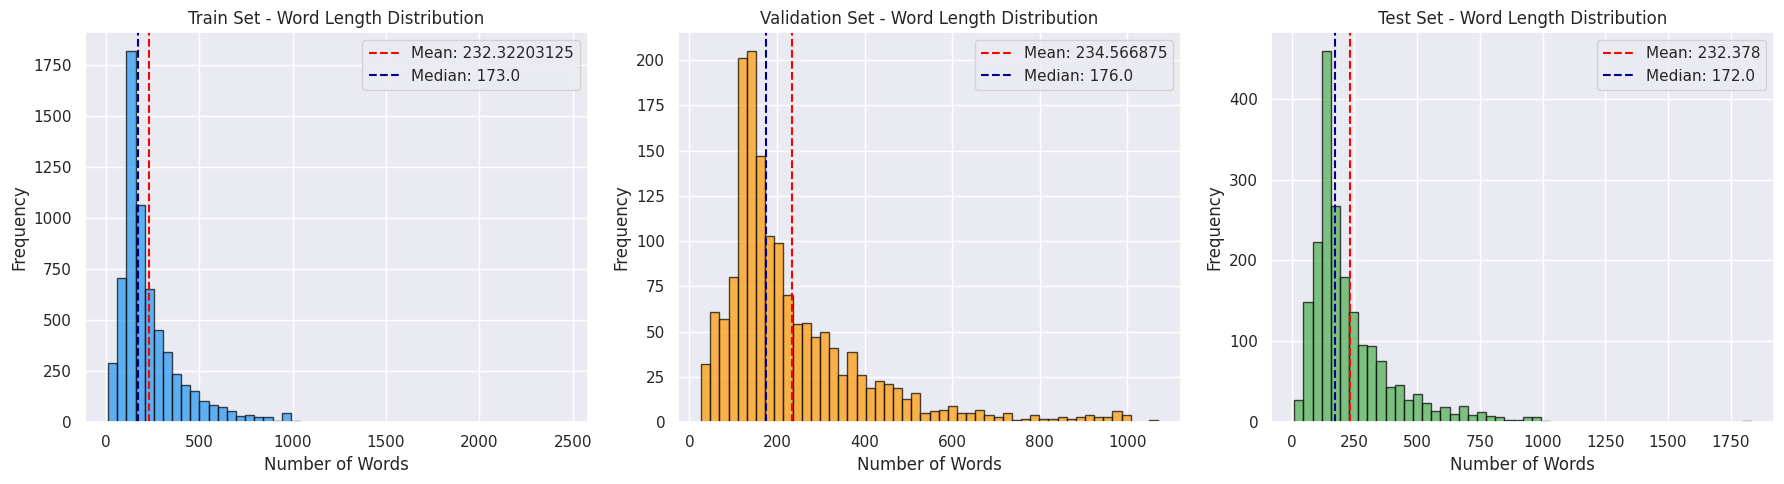

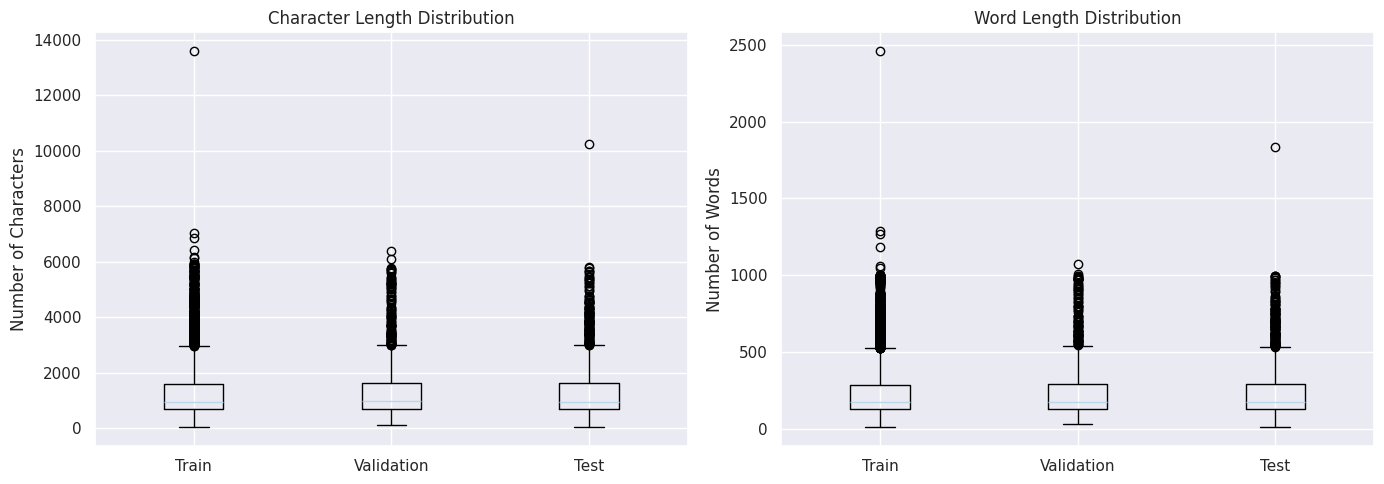

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ["#2196F3", "#FF9800", "#4CAF50"]

for ax, (split_name, texts), color in zip(axes, splits.items(), colors):
    word_lengths = [len(t.split()) for t in texts]

    ax.hist(word_lengths, bins=50, color=color, edgecolor="black", alpha=0.7)
    ax.axvline(np.mean(word_lengths), color="red", linestyle="--",
               label=f"Mean: {np.mean(word_lengths)}")
    ax.axvline(np.median(word_lengths), color="darkblue", linestyle="--",
               label=f"Median: {np.median(word_lengths)}")
    ax.set_title(f"{split_name} Set - Word Length Distribution")
    ax.set_xlabel("Number of Words")
    ax.set_ylabel("Frequency")
    ax.legend()

    print(f"{split_name}: Mean={np.mean(word_lengths)}, "
          f"Median={np.median(word_lengths)}, "
          f"Min={np.min(word_lengths)}, Max={np.max(word_lengths)}, "
          f"Std={np.std(word_lengths)}")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

char_data = [[len(t) for t in texts] for texts in splits.values()]
word_data = [[len(t.split()) for t in texts] for texts in splits.values()]

axes[0].boxplot(char_data, labels=splits.keys())
axes[0].set_title("Character Length Distribution")
axes[0].set_ylabel("Number of Characters")

axes[1].boxplot(word_data, labels=splits.keys())
axes[1].set_title("Word Length Distribution")
axes[1].set_ylabel("Number of Words")

plt.tight_layout()
plt.show()

En este caso tenemos una mediana sobre 175 palabras y un tamaño máximo cercano a 1000 palabras en las reviews procesadas.

Tendré esto en cuenta a la hora de calcular cuánto sería el tamaño de una secuencia de entrada sobre todo para el caso de la evaluación few-shot. Donde de mediana una entrada podría ser:
num_ejemplos x 175 + 1 x 175 + len_instruccion.
Si num_ejemplos=2 y len_instruccion=20 tendríamos alrededor de: 545 palabras. Muchos LLMs implementan sub-word tokenization. Es decir, que una palabra no es directamente un token si no una sílaba o un conjunto de letras en concreto.
Si tenemos 545 palabras en inglés, quizá estamos hablando siendo pesimistas de 545 x 3 = 1635 tokens de entrada.

# LLMs

Vamos a empezar a definiendo la configuración del modelo y lo cargaremos en memoria.
La pipeline de hugging face que vamos a utilizar es **AutoModelForCausalLM** (como se indica en la documentación del modelo:
https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.3#function-calling-with-transformers)

Esta pipeline es la típica de un LLM donde el modelo predice el siguiente token basado solamente en los tokens anteriores.

In [18]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
from torch.utils.data import DataLoader
import re
from typing import List, Dict, Tuple, Optional
import json

## Configuration

He añadido un parámetro TEST_SUBSET_SIZE para ayudarme a ejecutar las celdas de evaluación más rápidamente con un subset pequeño de test.
Si es None, se escoge todo el dataset de test, así es como lo he ejecutado al final. Solo lo he usado para iterar en código, pero no para los resultados.

In [19]:
TEST_SUBSET_SIZE = None

# Número de ejemplos en el prompt few-shot
NUM_FEW_SHOT_EXAMPLES = 2
MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.3"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Número máximo que de tokens que el modelo puede predecir.
# 10 tiene sentido para predecir solamente positivo - negativo
# Pero no para usar chain-of-thought si además predice el razonamiento.
MAX_NEW_TOKENS = 10
# Pruebo con un valor bajo de temperatura porque quiero predicciones precisas.
TEMPERATURE = 0.2
RANDOM_SEED = 42

print(f"Using device: {DEVICE}")

Using device: cuda


Creo un directorio para guardar resultados de evaluación.

In [20]:
import os

os.makedirs('llm_results', exist_ok=True)

Función para escoger un subset de los datos de test.
Si el tamaño pasado es None, usamos todos los datos de test.

In [21]:
def get_test_subset(test_dataset, subset_size=None, seed=42):
    if subset_size is None or subset_size >= len(test_dataset):
        return test_dataset
    
    # Shuffle and select subset
    shuffled = test_dataset.shuffle(seed=seed)
    return shuffled.select(range(subset_size))

Preparamos los datos de test

In [22]:
test_data = get_test_subset(dataset_dict['test'], subset_size=TEST_SUBSET_SIZE, seed=RANDOM_SEED)

print(f"Test data size: {len(test_data)}")
print(f"Sample test example:")
print(test_data[0]['text'])
print(test_data[0]['id'])
print(test_data[0]['label'])


Test data size: 2000
Sample test example:
Movies about dinosaurs can be entertaining. So can Whoopi Goldberg movies. But Whoopi AND dinosaurs? After the first 20 minutes of "Theodore Rex", I had come to one conclusion: this movie is evil. Evil, vile, wicked and reprehensible in its spite for the audience. Nothing this bad is made by accident; this is the visual equivalent of a torture chamber. First of all, Whoopi does not make good action movies (watch "Fatal Beauty" if you think I'm lying), but the film makers don't care - she's a tough cop here, yet again. Seen a million cop buddy flicks this week? Well, here's number one million and one, pal. Don't like cute, humanistic animated dinosaurs since that Spielberg TV show about them? Too bad, here's another one and he's a cop, too! You one of those people that hates car chases, shoot-outs, sloppy dialogue, boring futuristic FX and seeing talented people (Goldberg, Mueller-Stahl, Roundtree) stuck in a movie that looks like a tax write-of

## Cargamos el modelo y tokenizador

In [23]:
from transformers import BitsAndBytesConfig

print(f"Loading model: {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# Para hacer inferencia en batches las secuencias en un batch deberán tener la misma longitud.
# Seleccionamos un token para padding hasta la secuencia más larga del batch.
tokenizer.pad_token = tokenizer.eos_token

quantization_config = BitsAndBytesConfig(load_in_8bit=True)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quantization_config,
    device_map="auto"
)

model.eval()

Loading model: mistralai/Mistral-7B-Instruct-v0.3...


2026-04-29 19:25:37.617009: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Loading checkpoint shards: 100%|██████████| 3/3 [00:19<00:00,  6.36s/it]


MistralForCausalLM(
  (model): MistralModel(
    (embed_tokens): Embedding(32768, 4096)
    (layers): ModuleList(
      (0-31): 32 x MistralDecoderLayer(
        (self_attn): MistralAttention(
          (q_proj): Linear8bitLt(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear8bitLt(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear8bitLt(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear8bitLt(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): MistralMLP(
          (gate_proj): Linear8bitLt(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear8bitLt(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear8bitLt(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): MistralRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): MistralRMSNorm((4096,), eps=1e-05)
      

Vemos el número de parámetros y cuánto ocupa el modelo en memoria.
Solo con el modelo, ahora estamos ocupando **7.5GB de GPU**.

In [24]:
print(f"Model parameters: {sum(p.numel() for p in model.parameters()) / 1e9}B")
print(f"Model size in memory: {sum(p.numel() * p.element_size() for p in model.parameters()) / 1e9} GB")

Model parameters: 7.248023552B
Model size in memory: 7.516725248 GB


Los modelos generativos producen en la salida texto (después de su propio postprocesado). Tenemos que discretizar los tokens (raw string) predicho en
nuestras clases de clasificación. Para esto tenemos la siguiente función:

In [25]:
def parse_sentiment(generated_text: str):
    text_lower = generated_text.lower().strip()

    # Try to find "positive" or "negative" in the output
    if "positive" in text_lower:
        return 1
    elif "negative" in text_lower:
        return 0

    return None

Utilizaremos la siguiente función en todos los experimentos que hagamos para evaluar el modelo en los datos.

In [26]:
import time

MAX_INPUT_LEN = 4096

def run_inference(prompts: List[str], model, tokenizer, device, max_new_tokens=10, temperature=0.7, batch_size=1):
    generated_texts = []
    
    start_time = time.time()

    # Quiero detectar si algún prompt es más largo que la longitud máxima
    # sería peligroso porque se truncaría el prompt y se perdería información.
    for i, prompt in enumerate(prompts):
        token_len = len(tokenizer.encode(prompt))
        if token_len > MAX_INPUT_LEN:
            raise ValueError(
                f"[WARNING] Prompt {i} exceeds max length: {token_len} tokens > {MAX_INPUT_LEN}. Prompt will be truncated."
            )

    for i in tqdm(range(0, len(prompts), batch_size), desc="Running inference"):
        batch_prompts = prompts[i:i+batch_size]

        # Tokenizar el batch - Con padding y truncar si excede max input len.
        inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True, truncation=True, max_length=MAX_INPUT_LEN)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # Generate
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id if tokenizer.eos_token_id else tokenizer.pad_token_id
            )

        # Decodificamos las predicciones y las añadimos a la lista
        batch_texts = tokenizer.batch_decode(outputs[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)
        generated_texts.extend(batch_texts)

    elapsed = time.time() - start_time
    print(f"Inference completed: {len(prompts)} prompts in {elapsed}s")

    return generated_texts

Con la anterior función solamente obtenemos las predicciones. Mediante la siguiente función,
comparamos las predicciones con las etiquetas.

Como en las prácticas anteriores usamos:
- accuracy_score
- confusion_matrix
- classification_report

In [27]:
def evaluate_predictions(y_true, y_pred, ids, generated_texts, approach_name="Approach"):
    # Es posible que tengamos errores al parsear la salida del modelo (por ejemplo si el modelo no predice ni positive o negative).
    # tendremos un None en la predicción y tenemos que manejar este caso
    valid_indices = [i for i, pred in enumerate(y_pred) if pred is not None]

    if len(valid_indices) < len(y_pred):
        print(f"Warning: {len(y_pred) - len(valid_indices)} predictions could not be parsed")

    y_true_valid = [y_true[i] for i in valid_indices]
    y_pred_valid = [y_pred[i] for i in valid_indices]
    ids_valid = [ids[i] for i in valid_indices]
    texts_valid = [generated_texts[i] for i in valid_indices]

    # Calculate metrics
    accuracy = accuracy_score(y_true_valid, y_pred_valid)
    cm = confusion_matrix(y_true_valid, y_pred_valid)

    print(f"Total samples: {len(y_true)}")
    print(f"Valid predictions: {len(valid_indices)}")
    print(f"Failed to parse: {len(y_pred) - len(valid_indices)}")
    print(f"Accuracy: {accuracy}")

    print(f"Classification Report:")
    print(classification_report(y_true_valid, y_pred_valid, target_names=target_labels))

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_labels, yticklabels=target_labels)
    plt.title(f'{approach_name} - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    results = {
        'approach': approach_name,
        'accuracy': accuracy,
        'confusion_matrix': cm,
        'total_samples': len(y_true),
        'valid_predictions': len(valid_indices),
        'failed_predictions': len(y_pred) - len(valid_indices),
        'predictions': list(zip(ids_valid, y_true_valid, y_pred_valid, texts_valid))
    }
    
    return results

## Evaluación Zero-shot

Comenzamos por una evaluación zero-shot. En esta no se le pasan ejemplos al modelo. En el prompt indicaremos la instrucción
y cómo tiene que devolver la respuesta el modelo.

In [28]:
def create_zero_shot_prompt(review_text: str) -> str:
    prompt = f"""Classify the sentiment of the following movie review as either "positive" or "negative".

Review: {review_text}

Sentiment:"""

    return prompt

En la siguiente celda hacemos la inferencia **zero-shot**.

In [29]:
zero_shot_prompts = [create_zero_shot_prompt(example['text']) for example in test_data]

print(f"Zero-shot inference")
zero_shot_outputs = run_inference(
    zero_shot_prompts, 
    model, 
    tokenizer, 
    DEVICE, 
    max_new_tokens=MAX_NEW_TOKENS,
    temperature=TEMPERATURE,
    batch_size=8
)

zero_shot_predictions = [parse_sentiment(output) for output in zero_shot_outputs]

Zero-shot inference


Running inference: 100%|██████████| 250/250 [09:34<00:00,  2.30s/it]

Inference completed: 2000 prompts in 574.9553134441376s


In [30]:
print("Sample predictions:")
for i in range(min(3, len(zero_shot_outputs))):
    print("---")
    print(f"Example {i+1}:")
    print(f"Review: {test_data[i]['text']}...")
    print(f"True label: {target_labels[test_data[i]['label']]}")
    print(f"Model output: '{zero_shot_outputs[i]}'")
    print(f"Parsed prediction: {target_labels[zero_shot_predictions[i]] if zero_shot_predictions[i] is not None else 'FAILED TO PARSE'}")

Sample predictions:
---
Example 1:
Review: Movies about dinosaurs can be entertaining. So can Whoopi Goldberg movies. But Whoopi AND dinosaurs? After the first 20 minutes of "Theodore Rex", I had come to one conclusion: this movie is evil. Evil, vile, wicked and reprehensible in its spite for the audience. Nothing this bad is made by accident; this is the visual equivalent of a torture chamber. First of all, Whoopi does not make good action movies (watch "Fatal Beauty" if you think I'm lying), but the film makers don't care - she's a tough cop here, yet again. Seen a million cop buddy flicks this week? Well, here's number one million and one, pal. Don't like cute, humanistic animated dinosaurs since that Spielberg TV show about them? Too bad, here's another one and he's a cop, too! You one of those people that hates car chases, shoot-outs, sloppy dialogue, boring futuristic FX and seeing talented people (Goldberg, Mueller-Stahl, Roundtree) stuck in a movie that looks like a tax write-o

Ahora evaluamos las predicciones contra las etiquetas.

Total samples: 2000
Valid predictions: 1937
Failed to parse: 63
Accuracy: 0.9504388229220444
Classification Report:
              precision    recall  f1-score   support

    negative       0.94      0.97      0.95       995
    positive       0.97      0.93      0.95       942

    accuracy                           0.95      1937
   macro avg       0.95      0.95      0.95      1937
weighted avg       0.95      0.95      0.95      1937



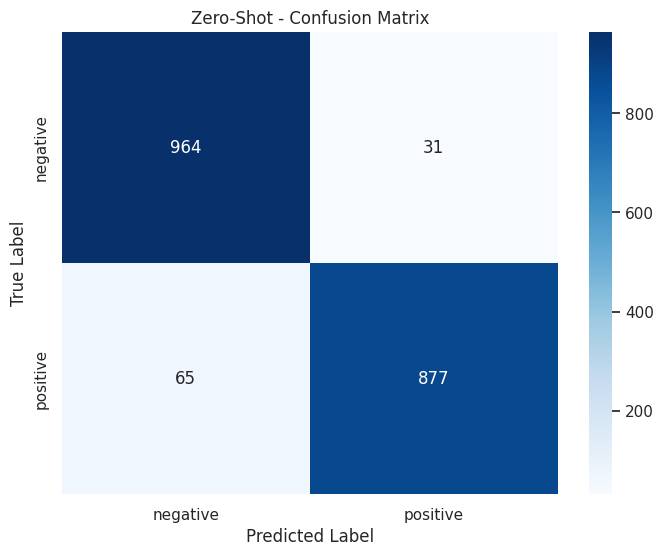

In [31]:
zero_shot_results = evaluate_predictions(
    y_true=[example['label'] for example in test_data],
    y_pred=zero_shot_predictions,
    ids=[example['id'] for example in test_data],
    generated_texts=zero_shot_outputs,
    approach_name="Zero-Shot"
)

Guardamos los resultados de evaluación

In [32]:
zero_shot_df = pd.DataFrame(zero_shot_results['predictions'], columns=['id', 'true_label', 'predicted_label', 'model_output'])
zero_shot_df['true_sentiment'] = zero_shot_df['true_label'].apply(lambda x: target_labels[x])
zero_shot_df['predicted_sentiment'] = zero_shot_df['predicted_label'].apply(lambda x: target_labels[x])
zero_shot_df.to_csv('llm_results/zero_shot_predictions.csv', index=False)


## Evaluación Few-shot

Ahora vamos a emplear la técnica few-shot donde escogeremos al menos un ejemplo de cada clase para añadirla al prompt.

In [33]:
def select_few_shot_examples(train_dataset, num_examples=3, seed=42):
    examples_by_class = {0: [], 1: []}

    # Ordenamos los ejemplos por etiqueta y así podemos escoger ejemplos
    # según la clase
    for example in train_dataset:
        label = example['label']
        examples_by_class[label].append(example)

    np.random.seed(seed)
    selected_examples = []

    for label in [0, 1]:
        class_examples = examples_by_class[label]
        sampled = np.random.choice(len(class_examples), size=min(num_examples, len(class_examples)), replace=False)
        selected_examples.extend([class_examples[i] for i in sampled])

    return selected_examples

Creamos una función para construir el prompt few-shot, esta vez dado el texto a clasificar y los ejemplos.

In [34]:
def create_few_shot_prompt(review_text: str, examples) -> str:
    prompt = "Classify the sentiment of movie reviews as either \"positive\" or \"negative\".\n\n"

    for example in examples:
        sentiment = target_labels[example['label']]
        prompt += f"Review: {example['text']}\nSentiment: {sentiment}\n\n"

    prompt += f"Review: {review_text}\nSentiment:"

    return prompt

Seleccionamos los ejemplos del dataset para few-shot. Se seleccionan del dataset de **entrenamiento**.
En este caso tendremos 4 ejemplos: 2 para la clase positiva y 2 para la clase negativa.

In [35]:
few_shot_examples = select_few_shot_examples(
    dataset_dict['train'], 
    num_examples=NUM_FEW_SHOT_EXAMPLES, 
    seed=RANDOM_SEED
)

print(f"Selected {len(few_shot_examples)} few-shot examples:")
for i, example in enumerate(few_shot_examples):
    print(f"Example {i+1}:")
    print(f"Label: {target_labels[example['label']]}")
    print(f"Text: {example['text']}")

Selected 4 few-shot examples:
Example 1:
Label: negative
Text: This film is so bad and gets worse in every imaginable fashion. Its not just the poor acting and script nor is it the lame and perverse time one wastes on watching it. What really puts this film in my hall of shame is the apparent struggling that the writers and producers do with the film to try and make it funny. The actress replacing Jean Reno's descendant is to old and learned her lesson in the first film so they add a new girl who is to be married. Nearly all of the original extras and gags return however this time makes me want to ripe my eyes out of my sockets because it's a waste of perfectly good film. The torture of the constant camera cuts and shots in any scene in this movie can put the viewer into violent convolutions. This second film takes the successful original and drags it out of its coffin and parades the corpse out in the public square and perversely degrades not only the original idea and its legacy but 

Ahora hacemos la inferencia de los prompt few-shot.

In [36]:
few_shot_prompts = [create_few_shot_prompt(example['text'], few_shot_examples) for example in test_data]

# Show example prompt
print("Example few-shot prompt:")
print(few_shot_prompts[0])


Example few-shot prompt:
Classify the sentiment of movie reviews as either "positive" or "negative".

Review: This film is so bad and gets worse in every imaginable fashion. Its not just the poor acting and script nor is it the lame and perverse time one wastes on watching it. What really puts this film in my hall of shame is the apparent struggling that the writers and producers do with the film to try and make it funny. The actress replacing Jean Reno's descendant is to old and learned her lesson in the first film so they add a new girl who is to be married. Nearly all of the original extras and gags return however this time makes me want to ripe my eyes out of my sockets because it's a waste of perfectly good film. The torture of the constant camera cuts and shots in any scene in this movie can put the viewer into violent convolutions. This second film takes the successful original and drags it out of its coffin and parades the corpse out in the public square and perversely degrades

In [37]:
few_shot_outputs = run_inference(
    few_shot_prompts, 
    model, 
    tokenizer, 
    DEVICE, 
    max_new_tokens=MAX_NEW_TOKENS,
    temperature=TEMPERATURE,
    batch_size=4
)

few_shot_predictions = [parse_sentiment(output) for output in few_shot_outputs]

print("Sample predictions:")
for i in range(min(3, len(few_shot_outputs))):
    print("---")
    print(f"Example {i+1}:")
    print(f"Review: {test_data[i]['text']}")
    print(f"True label: {target_labels[test_data[i]['label']]}")
    print(f"Model output: '{few_shot_outputs[i]}'")
    print(f"Parsed prediction: {target_labels[few_shot_predictions[i]]}")

Running inference: 100%|██████████| 500/500 [26:33<00:00,  3.19s/it]

Inference completed: 2000 prompts in 1596.6546430587769s
Sample predictions:
---
Example 1:
Review: Movies about dinosaurs can be entertaining. So can Whoopi Goldberg movies. But Whoopi AND dinosaurs? After the first 20 minutes of "Theodore Rex", I had come to one conclusion: this movie is evil. Evil, vile, wicked and reprehensible in its spite for the audience. Nothing this bad is made by accident; this is the visual equivalent of a torture chamber. First of all, Whoopi does not make good action movies (watch "Fatal Beauty" if you think I'm lying), but the film makers don't care - she's a tough cop here, yet again. Seen a million cop buddy flicks this week? Well, here's number one million and one, pal. Don't like cute, humanistic animated dinosaurs since that Spielberg TV show about them? Too bad, here's another one and he's a cop, too! You one of those people that hates car chases, shoot-outs, sloppy dialogue, boring futuristic FX and seeing talented people (Goldberg, Mueller-Stahl, 

Ahora comparamos las predicciones few-shot con las etiquetas.

Total samples: 2000
Valid predictions: 1990
Failed to parse: 10
Accuracy: 0.9522613065326633
Classification Report:
              precision    recall  f1-score   support

    negative       0.97      0.94      0.95      1019
    positive       0.93      0.97      0.95       971

    accuracy                           0.95      1990
   macro avg       0.95      0.95      0.95      1990
weighted avg       0.95      0.95      0.95      1990



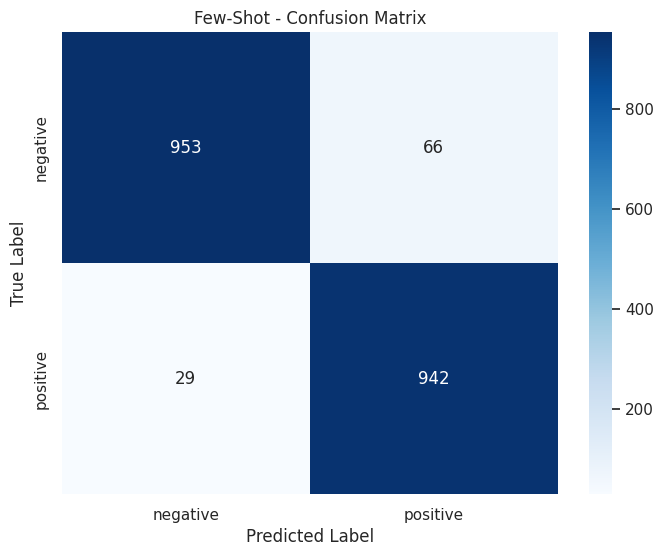

In [38]:
few_shot_results = evaluate_predictions(
    y_true=[example['label'] for example in test_data],
    y_pred=few_shot_predictions,
    ids=[example['id'] for example in test_data],
    generated_texts=few_shot_outputs,
    approach_name="Few-Shot"
)

Guardamos los resultados.

In [39]:
few_shot_df = pd.DataFrame(few_shot_results['predictions'], columns=['id', 'true_label', 'predicted_label', 'model_output'])
few_shot_df['true_sentiment'] = few_shot_df['true_label'].apply(lambda x: target_labels[x])
few_shot_df['predicted_sentiment'] = few_shot_df['predicted_label'].apply(lambda x: target_labels[x])
few_shot_df.to_csv('llm_results/few_shot_predictions.csv', index=False)


## Chain-of-thought

En este caso utilizaremos la idea de chain-of-thought para solicitar al modelo que genere pasos intermedios. Por ejemplo, podemos pedir que primero
genere una lista palabras clave con sentimiento y que las clasifique; que nos dé el tono de la reseña y por último que la clasifique.

Vamos a pedirle también que la respuesta que de sea en el formato JSON para que podamos capturar las palabras clave con sentimiento, el tono y la clasificación.

He iterado dos veces con este prompt. Para limitar cierto comportamiento he añadido:
- "Neutral label is not allowed" - Encontré una predicción clasificada como "neutral".
- Si el modelo predice demasiadas keywords hay un riesgo de truncar la salida y se pierde la clasificación. Por eso
he añadido: "where the maximum allowed keywords is 5".

In [40]:
def create_cot_prompt(review_text: str) -> str:
    prompt = f"""Classify the sentiment of the following movie review as either "positive" or "negative". Neutral label is not allowed.

Review: {review_text}

Let's think step by step, respond ONLY with a JSON object in this exact format where the maximum allowed keywords is 5:
{{
    "keywords": [
        {{"word": "<keyword>", "sentiment": "<positive/negative>"}},
        {{"word": "<keyword>", "sentiment": "<positive/negative>"}}
    ],
    "tone": "<brief description of overall tone>",
    "classification": "<positive/negative>"
}}

JSON Response:"""
    
    return prompt

Necesitaremos otra función para parsear la salida.

In [41]:
import json
import re

def parse_cot_response(response: str) -> dict:
    # Si se puede directamente parseamos a JSON
    try:
        return json.loads(response.strip())
    except json.JSONDecodeError:
        pass

    try:
        json_match = re.search(r'\{.*\}', response, re.DOTALL)
        if json_match:
            return json.loads(json_match.group())
    except json.JSONDecodeError:
        pass

    print("Could not parse JSON response. Returning raw response.")
    return {
        "keywords": [],
        "tone": None,
        "classification": None,
        "raw_response": response
    }

### Run Chain-of-Thought Inference

In [42]:
cot_prompts = [create_cot_prompt(example['text']) for example in test_data]

# Show example prompt
print("Example CoT prompt (first 500 chars):")
print(cot_prompts[0])

Example CoT prompt (first 500 chars):
Classify the sentiment of the following movie review as either "positive" or "negative". Neutral label is not allowed.

Review: Movies about dinosaurs can be entertaining. So can Whoopi Goldberg movies. But Whoopi AND dinosaurs? After the first 20 minutes of "Theodore Rex", I had come to one conclusion: this movie is evil. Evil, vile, wicked and reprehensible in its spite for the audience. Nothing this bad is made by accident; this is the visual equivalent of a torture chamber. First of all, Whoopi does not make good action movies (watch "Fatal Beauty" if you think I'm lying), but the film makers don't care - she's a tough cop here, yet again. Seen a million cop buddy flicks this week? Well, here's number one million and one, pal. Don't like cute, humanistic animated dinosaurs since that Spielberg TV show about them? Too bad, here's another one and he's a cop, too! You one of those people that hates car chases, shoot-outs, sloppy dialogue, boring f

Primero ejecutamos en algunas pruebas en entrenamiento.

In [43]:
cot_train_prompts = [create_cot_prompt(example['text']) for example in train_dataset]

cot_train_outputs = run_inference(
    cot_train_prompts[0:5], 
    model, 
    tokenizer, 
    DEVICE, 
    max_new_tokens=248,
    temperature=TEMPERATURE,
    batch_size=4
)

cot_train_predictions = [parse_cot_response(output) for output in cot_train_outputs]

Running inference: 100%|██████████| 2/2 [00:27<00:00, 13.57s/it]

Inference completed: 5 prompts in 27.14447546005249s


In [44]:
print("Sample predictions:")
for i in range(min(3, len(cot_train_outputs))):
    print(f"Example {i+1}:")
    print(f"Review: {test_data[i]['text']}")
    print(f"True label: {target_labels[test_data[i]['label']]}")
    print(f"Model output: '{cot_train_predictions[i]['classification']}'")

Sample predictions:
Example 1:
Review: Movies about dinosaurs can be entertaining. So can Whoopi Goldberg movies. But Whoopi AND dinosaurs? After the first 20 minutes of "Theodore Rex", I had come to one conclusion: this movie is evil. Evil, vile, wicked and reprehensible in its spite for the audience. Nothing this bad is made by accident; this is the visual equivalent of a torture chamber. First of all, Whoopi does not make good action movies (watch "Fatal Beauty" if you think I'm lying), but the film makers don't care - she's a tough cop here, yet again. Seen a million cop buddy flicks this week? Well, here's number one million and one, pal. Don't like cute, humanistic animated dinosaurs since that Spielberg TV show about them? Too bad, here's another one and he's a cop, too! You one of those people that hates car chases, shoot-outs, sloppy dialogue, boring futuristic FX and seeing talented people (Goldberg, Mueller-Stahl, Roundtree) stuck in a movie that looks like a tax write-off? 

In [45]:
print("Running chain-of-thought inference...")
cot_outputs = run_inference(
    cot_prompts, 
    model, 
    tokenizer, 
    DEVICE, 
    max_new_tokens=248,
    temperature=TEMPERATURE,
    batch_size=12
)

Running chain-of-thought inference...


Running inference: 100%|██████████| 167/167 [1:07:53<00:00, 24.40s/it]

Inference completed: 2000 prompts in 4074.8966398239136s


In [46]:
cot_predictions = [parse_cot_response(output) for output in cot_outputs]

label_to_int = {"negative": 0, "positive": 1}

cot_pred_bin = [
    label_to_int.get(pred["classification"].lower().strip(), None) 
    if pred["classification"] is not None 
    else None 
    for pred in cot_predictions
]

print("Sample predictions:")
for i in range(min(3, len(cot_outputs))):
    print(f"Example {i+1}:")
    print(f"Review: {test_data[i]['text']}")
    print(f"True label: {target_labels[test_data[i]['label']]}")
    print(f"Model output: '{cot_outputs[i]}'")
    print(f"Parsed prediction: {target_labels[cot_pred_bin[i]] if cot_pred_bin[i] is not None else 'FAILED TO PARSE'}")

Could not parse JSON response. Returning raw response.
Could not parse JSON response. Returning raw response.
Could not parse JSON response. Returning raw response.
Could not parse JSON response. Returning raw response.
Could not parse JSON response. Returning raw response.
Could not parse JSON response. Returning raw response.
Could not parse JSON response. Returning raw response.
Could not parse JSON response. Returning raw response.
Could not parse JSON response. Returning raw response.
Could not parse JSON response. Returning raw response.
Could not parse JSON response. Returning raw response.
Sample predictions:
Example 1:
Review: Movies about dinosaurs can be entertaining. So can Whoopi Goldberg movies. But Whoopi AND dinosaurs? After the first 20 minutes of "Theodore Rex", I had come to one conclusion: this movie is evil. Evil, vile, wicked and reprehensible in its spite for the audience. Nothing this bad is made by accident; this is the visual equivalent of a torture chamber. F

### Evaluate Chain-of-Thought Results

Total samples: 2000
Valid predictions: 1969
Failed to parse: 31
Accuracy: 0.92534281361097
Classification Report:
              precision    recall  f1-score   support

    negative       0.89      0.97      0.93      1014
    positive       0.96      0.88      0.92       955

    accuracy                           0.93      1969
   macro avg       0.93      0.92      0.92      1969
weighted avg       0.93      0.93      0.93      1969



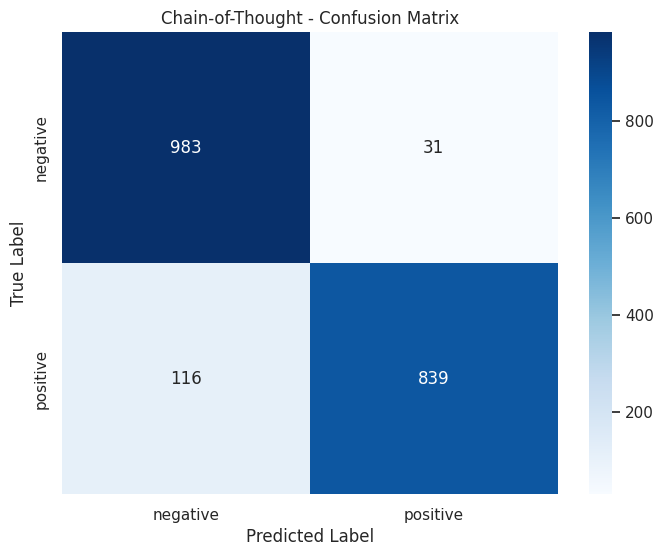

In [47]:
# Evaluate chain-of-thought approach
cot_results = evaluate_predictions(
    y_true=[example['label'] for example in test_data],
    y_pred=cot_pred_bin,
    ids=[example['id'] for example in test_data],
    generated_texts=cot_outputs,
    approach_name="Chain-of-Thought"
)

# Comparison of Approaches

Vamos a comparar en un mismo gráfico de barras todos los experimentos.

        Approach  Accuracy  Valid Predictions  Failed Predictions
       Zero-Shot  0.950439               1937                  63
        Few-Shot  0.952261               1990                  10
Chain-of-Thought  0.925343               1969                  31


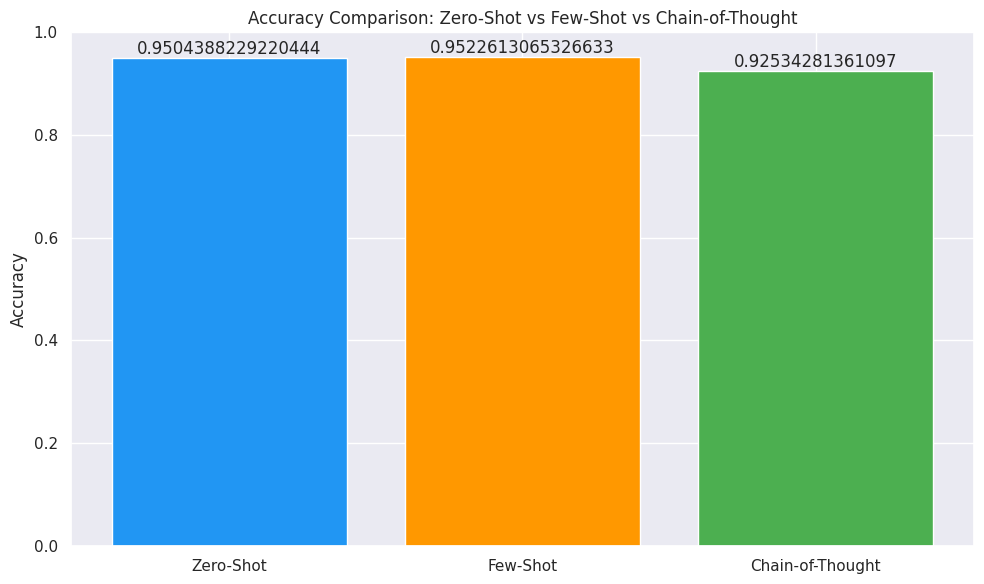

In [48]:
comparison_df = pd.DataFrame({
    'Approach': [zero_shot_results['approach'], few_shot_results['approach'], cot_results['approach']],
    'Accuracy': [zero_shot_results['accuracy'], few_shot_results['accuracy'], cot_results['accuracy']],
    'Valid Predictions': [zero_shot_results['valid_predictions'], few_shot_results['valid_predictions'], cot_results['valid_predictions']],
    'Failed Predictions': [zero_shot_results['failed_predictions'], few_shot_results['failed_predictions'], cot_results['failed_predictions']]
})

print(comparison_df.to_string(index=False))

plt.figure(figsize=(10, 6))
bars = plt.bar(comparison_df['Approach'], comparison_df['Accuracy'], color=['#2196F3', '#FF9800', '#4CAF50'])
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison: Zero-Shot vs Few-Shot vs Chain-of-Thought')
plt.ylim([0, 1.0])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

Guardamos los resultados.

In [49]:
cot_df = pd.DataFrame(cot_results['predictions'], columns=['id', 'true_label', 'predicted_label', 'model_output'])
cot_df['true_sentiment'] = cot_df['true_label'].apply(lambda x: target_labels[x])
cot_df['predicted_sentiment'] = cot_df['predicted_label'].apply(lambda x: target_labels[x])
cot_df.to_csv('llm_results/cot_predictions.csv', index=False)

comparison_df.to_csv('llm_results/comparison_summary.csv', index=False)

---

## Usage Instructions

### Prerequisites
Install required libraries for 8-bit quantization:
```bash
pip install bitsandbytes accelerate
```

### Quick Start
1. **Adjust Configuration** (in the Configuration cell):
   - Set `TEST_SUBSET_SIZE = 100` for quick testing
   - Set `TEST_SUBSET_SIZE = None` to run on the full test set (2000 samples)
   - Adjust `NUM_FEW_SHOT_EXAMPLES` to control how many examples are shown
   - Change `MODEL_NAME` to try different 7B causal models (e.g., "mistralai/Mistral-7B-Instruct-v0.2")

2. **Run All Cells** to execute the full pipeline for all three approaches

3. **View Results**:
   - Accuracy and confusion matrices are displayed after each approach
   - Final comparison table and visualization at the end
   - Detailed predictions saved in `llm_results/` directory

### Notes
- Model loads with **8-bit quantization** (~7GB VRAM for 7B models)
- Sample IDs track which test samples were evaluated
- Few-shot examples randomly selected from training set
- For faster experimentation, use a subset of test data first